## Figure 3 - Population responses across experience levels

This script generates Figure 3, showing population neural
responses to image changes and omissions across experience levels (Familiar, Novel, Novel+),
including single cell examples, population averages, response heatmaps, fraction of
responsive cells, and experience modulation indices.

In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse
import visual_behavior.ophys.response_analysis.cell_metrics as cm
import visual_behavior.dimensionality_reduction.clustering.processing as processing

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

%load_ext autoreload
%autoreload
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_3')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

folder = 'population_activity'

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [4]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

### Response metrics and multi-session dataframes 

In [ ]:
data_type = 'events'
interpolate = True
output_sampling_rate = 30

session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

#### Cell response metrics metrics

In [ ]:
metrics_dir = loading.get_cell_metrics_dir()
filepath = os.path.join(metrics_dir, f'merged_model_free_metrics_table_{data_type}_{inclusion_criteria}.csv')
filtered_events_metrics_table = pd.read_csv(filepath, index_col=0)

metrics_table = filtered_events_metrics_table.copy()

# Merge with platform experiments
metrics_table = metrics_table.merge(platform_experiments.reset_index(),
                                   on=['ophys_experiment_id', 'experience_level'])

#### Multi session response dataframes

In [ ]:
# Image changes
event_type = 'all'
conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

change_mdf = multi_session_df[multi_session_df.is_change == True]
image_mdf = multi_session_df[multi_session_df.is_change == False]

# Omissions
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]

# Per image
conditions = ['cell_specimen_id', 'is_change', 'image_name']
each_image_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)


print(len(change_mdf.ophys_experiment_id.unique()))
print(len(omission_mdf.ophys_experiment_id.unique()))
print(len(each_image_mdf.ophys_experiment_id.unique()))

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.pkl
there are 1881 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

...

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_image_name_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_image_name_platform_experiment_table.pkl
there are 1885 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


#### Dataset objects for all experiments for one field of view (container)

In [21]:
ophys_container_ids = [829561794]

# Load dataset dict for single cell plotting
# ophys_container_ids = matched_cells_table.ophys_container_id.unique()[:4]
dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids,
                                                       platform_experiments,
                                                       dataset_dict=None)

833629926


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

834279496


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

835006071


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

## Plotting

### Single cell examples

Example container and cells for matched cell plotting

array([<Axes: title={'center': '833629926'}>,
       <Axes: title={'center': '834279496'}>,
       <Axes: title={'center': '835006071'}>], dtype=object)

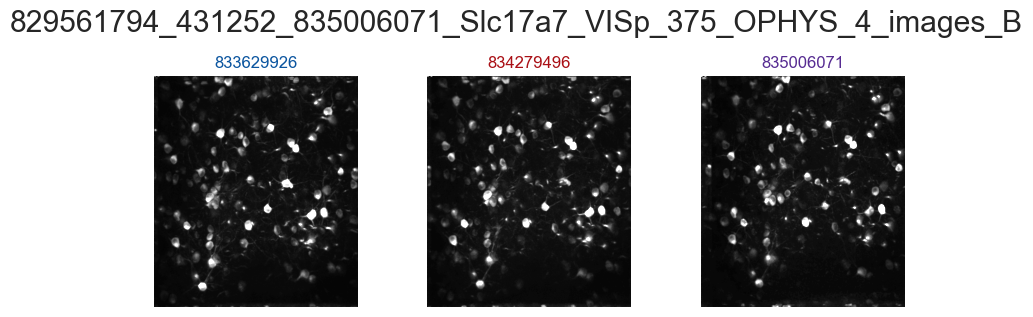

In [29]:
cell_type = 'Excitatory'

# Get high SNR matched cells for container
matched_cells_snr, dff_metrics = pse.get_high_snr_matched_cells_for_container(ophys_container_id, dataset_dict,
                                                                               matched_cells_table, platform_experiments, 
                                                                               )

# Plot matched max projections for container
# Note: function signature is (ophys_container_id, platform_experiments, dataset_dict, save_dir, ax)
# matched_cells_table is NOT a parameter
pse.plot_matched_max_projections_for_container(ophys_container_id, platform_experiments,
                                              dataset_dict,
                                              save_dir=save_dir, ax=None)



In [30]:

cell_type = 'Excitatory'

n_reliable_cells_threshold = 5

reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
            (change_mdf.mean_response > 0.02) &
            (change_mdf.cell_type==cell_type) & 
            (change_mdf.ophys_experiment_id.isin(platform_experiments.index.unique()))]

# reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]


In [31]:
start_times = np.asarray([512])
duration_seconds = 18

matched_cells = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id]
matched_cells = matched_cells.sort_values(by='fraction_significant_p_value_gray_screen', ascending=False)
matched_cells = matched_cells.drop_duplicates(subset='cell_specimen_id')
matched_cells = matched_cells.cell_specimen_id.values
print(len(matched_cells))

5


0 out of 1
833629926 Familiar 97 matched cells,  161 total cells
834279496 Novel 97 matched cells,  162 total cells
835006071 Novel + 97 matched cells,  146 total cells
using provided cell_specimen_ids in the order they were provided


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

saving


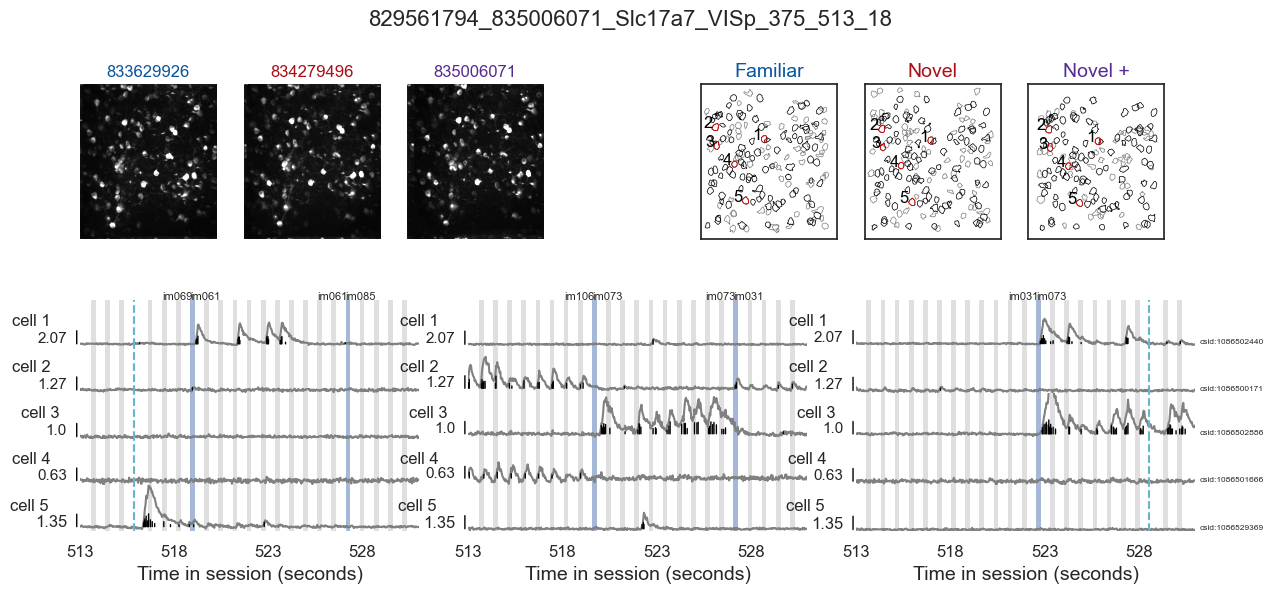

In [32]:
start_times = np.asarray([513])

csids = [1086502440, 
         1086500171,
         1086502886,
         1086501666, 
         1086529369]

pse.plot_matched_rois_and_traces_for_container(ophys_container_id, dataset_dict,
                                        matched_cells_table, platform_experiments, fontsize=12,
                                        start_times=start_times, duration_seconds=18,
                                        matched_cells=csids, save_dir=save_dir, suffix='')

0 out of 1
using provided cell_specimen_ids in the order they were provided


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

using provided cell_specimen_ids in the order they were provided


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

using provided cell_specimen_ids in the order they were provided
saving


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

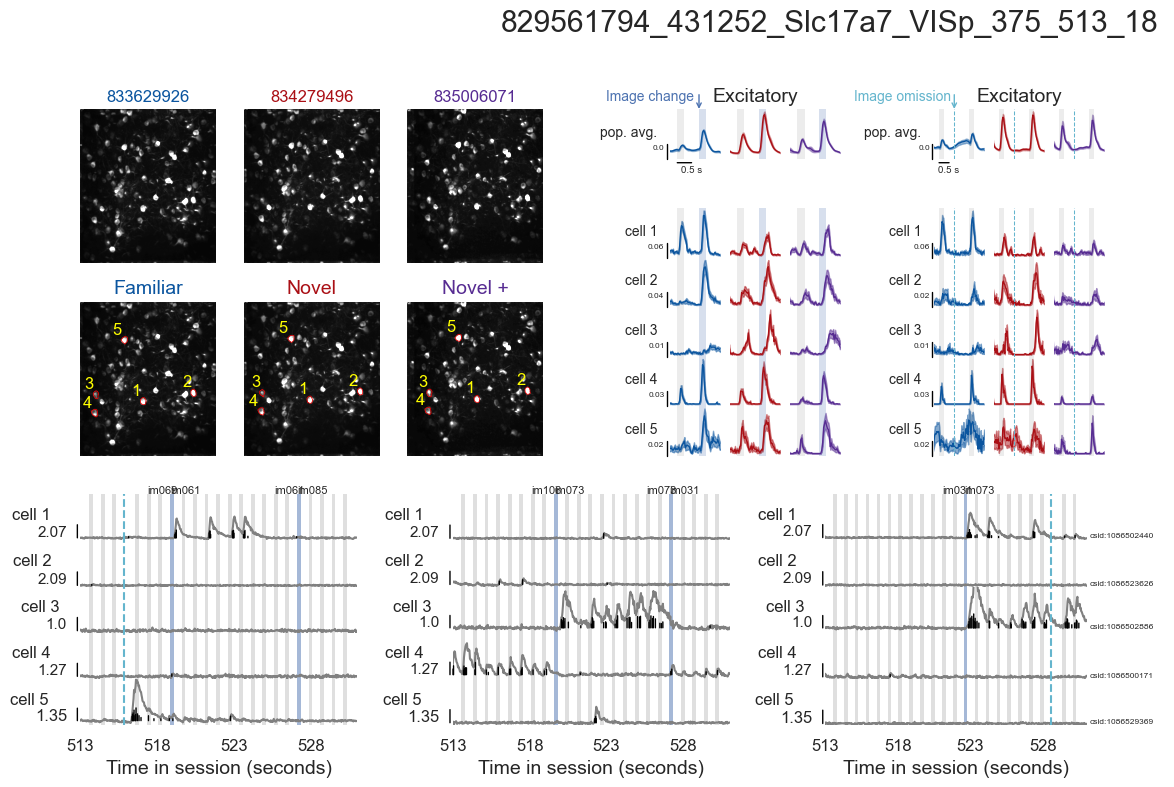

In [ ]:

suffix = '_reliable_cells_selected'

pse.plot_matched_traces_across_sessions(ophys_container_id, dataset_dict, 
                                    matched_cells_table, platform_experiments, 
                                    change_mdf, omission_mdf, cell_type, skip_behavior=True,
                                    start_times=start_times, duration_seconds=duration_seconds,
                                    matched_cells=matched_cells, save_dir=save_dir, suffix=suffix)

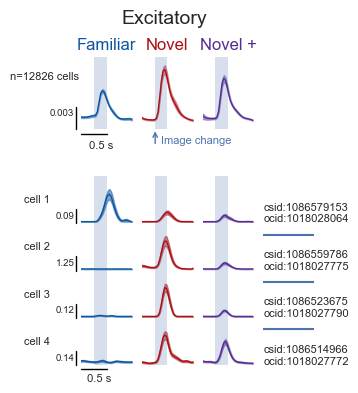

In [38]:
# Plot reliable example cells - changes
Exc_change_cells = [1086579153, 1086559786, 1086523675, 1086514966, 1086514622, 1120104688,
                    1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825]

pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type='changes',
                                save_dir=save_dir, folder='single_cell_examples', suffix='_selected')



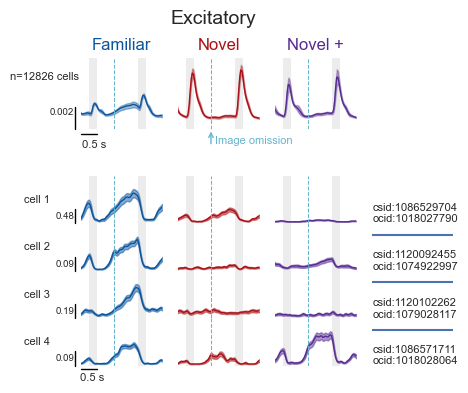

In [39]:
# Plot reliable example cells - omissions
Exc_omission_cells = [1086529704, 1120092455, 1120102262, 1086571711, 1086514606,
                      1086530117, 1120090879, 1086526518]

pse.plot_reliable_example_cells(omission_mdf, Exc_omission_cells[:4], cell_type, event_type='omissions',
                                save_dir=save_dir, folder='single_cell_examples', suffix='_selected')

### Reliable example cells 

#### Exc

#### Sst

11


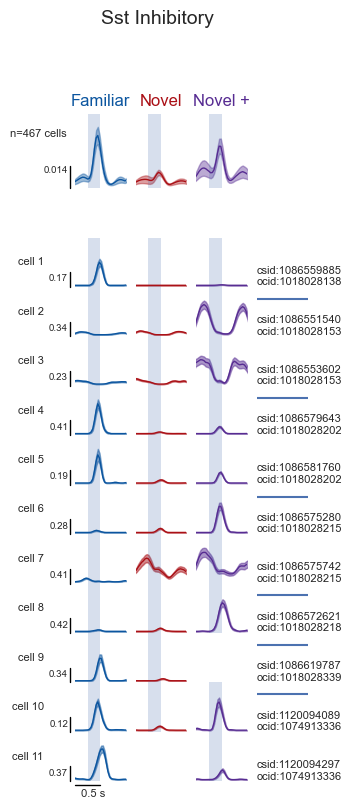

In [28]:
cell_type = 'Sst Inhibitory'

event_type = 'changes'
# get reliable cells for this cell type
reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
            (change_mdf.mean_response > 0.1) &
            (change_mdf.cell_type==cell_type)]
reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
cells_to_plot = reliable_cells.cell_specimen_id.unique()
print(len(cells_to_plot))

pse.plot_reliable_example_cells(change_mdf, cells_to_plot, cell_type, event_type=event_type, 
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

#### Vip

### Selected example cells for figure

In [40]:
Vip_containers = [1018027599, 1018027859, 1046576787, 1018027862, 1018028367]

Sst_containers = [1018028339, 1018028135, 1018028202, 1018028153, 1074913336]

Exc_containers = [1018027663, 1018027790, 1018028046, 1074922997, 1079028117, 1018027775,]


#### Changes

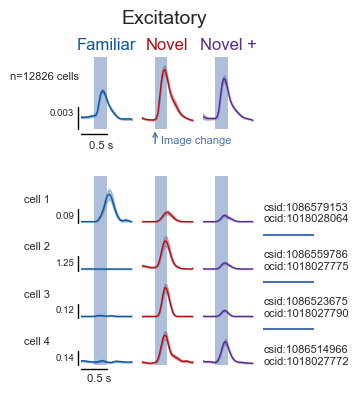

In [80]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, xlim_seconds=[-0.25, 0.75],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [81]:
xlim_seconds = [-1, 1.5]

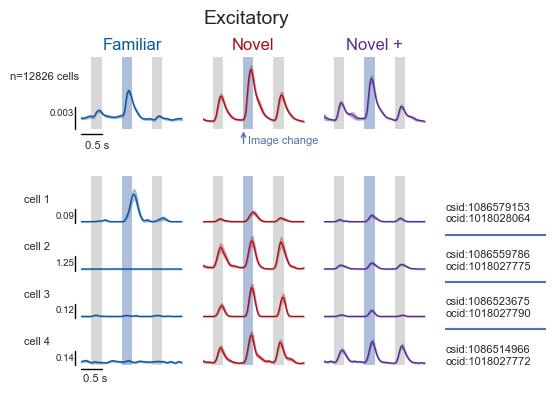

In [82]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, xlim_seconds=xlim_seconds,
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


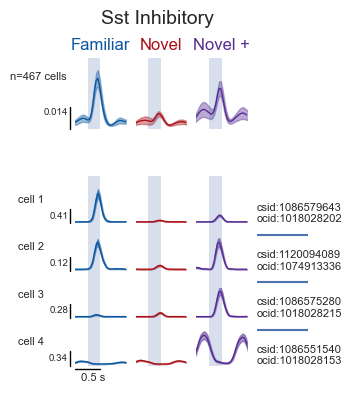

In [ ]:
Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
                    # 1086559885, 1086619787, 1086553602, 1120094297]
#1086575742, ]
cell_type = 'Sst Inhibitory'
pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, xlim_seconds=xlim_seconds,
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


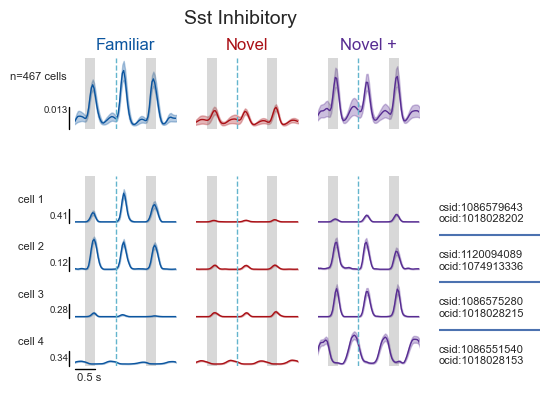

In [103]:
cell_type = 'Sst Inhibitory'
pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, xlim_seconds=[-1, 1.5],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

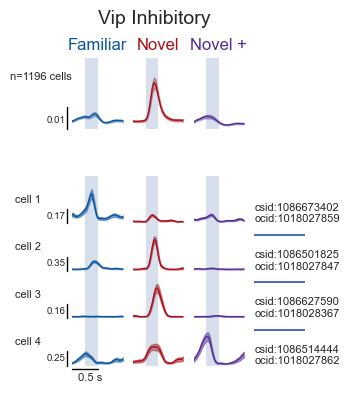

In [ ]:

Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 
# 1086627395, 1086673073, 1086519532, 1086516885, 1086615418, ]
event_type='changes'
cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(change_mdf, Vip_change_cells[:4], cell_type, event_type=event_type, xlim_seconds=xlim_seconds,
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


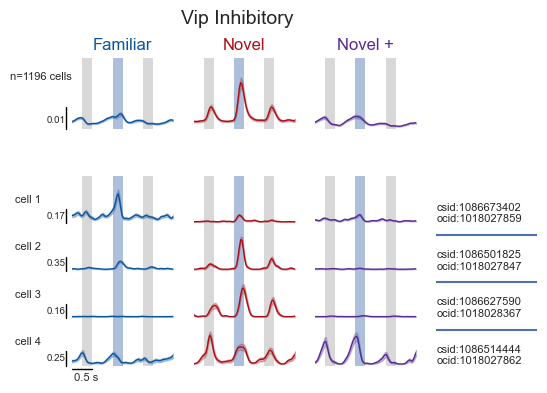

In [104]:
event_type='changes'
cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(change_mdf, Vip_change_cells[:4], cell_type, event_type=event_type, xlim_seconds=[-1, 1.5],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from image onset (s)'>, <Axes: >], dtype=object)

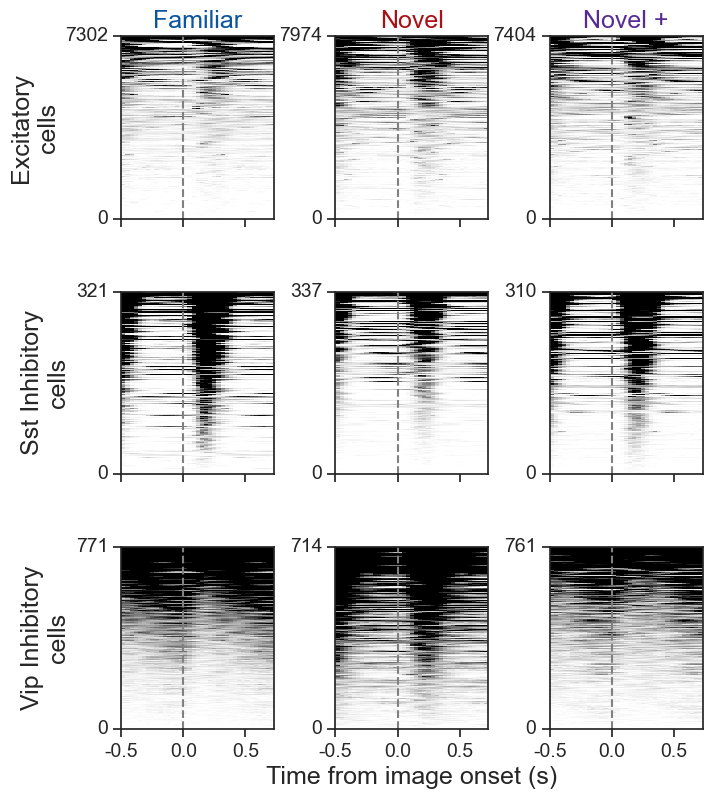

In [113]:
df = image_mdf.copy()

xlim_seconds = [-0.5, 0.75]

event_type = 'all'

timestamps = df.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'
cols_to_sort_by = ['mean_response']

ppf.plot_response_heatmaps_for_conditions(df, timestamps, data_type, event_type, row_condition, col_condition, 
                                          cols_to_sort_by=cols_to_sort_by, suptitle='', xlabel='Time from image onset (s)',
                                          microscope=None, vmax=None, xlim_seconds=xlim_seconds, match_cells=False, cbar=False,
                                          save_dir=save_dir, folder=folder, suffix='', ax=None)



array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from image change (s)'>, <Axes: >],
      dtype=object)

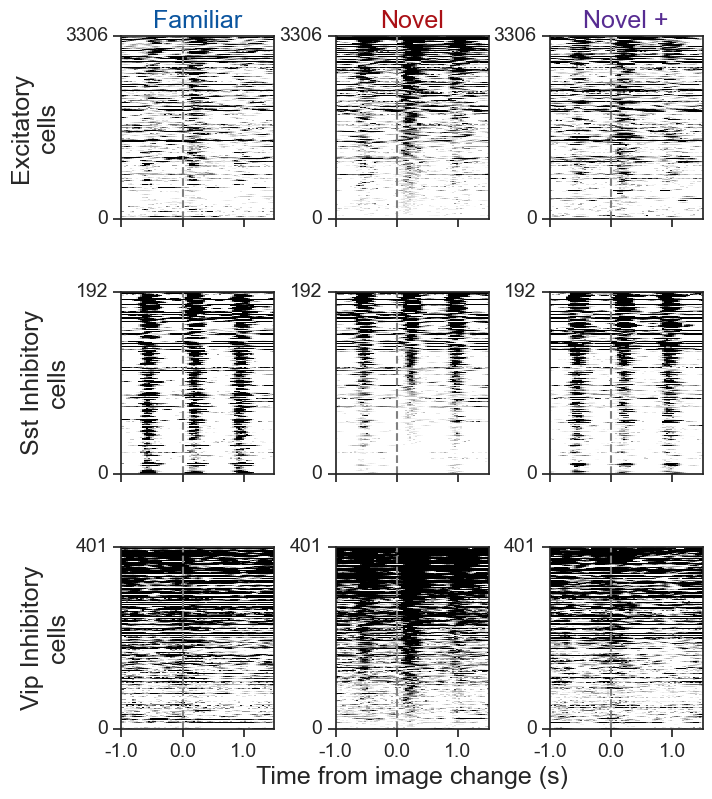

In [107]:
# Cell-matched response heatmaps for images
timestamps = change_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'
cols_to_sort_by = ['mean_response']

# Cell-matched population averages for changes
matched_changes = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(change_mdf)
xlim_seconds = [-1., 1.5]

# Cell-matched response heatmaps for changes
ppf.plot_response_heatmaps_for_conditions(
    matched_changes, timestamps, data_type, 'changes', row_condition, col_condition,
    cols_to_sort_by=None, suptitle='Matched cells - Changes',
    xlabel='Time from image change (s)',
    microscope=None, xlim_seconds=[-1, 1.5], match_cells=True, cbar=False,
    save_dir=save_dir, folder=folder, suffix='_matched_changes', ax=None)

#### Omissions

In [77]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
xlim_seconds = [-1, 1.5]

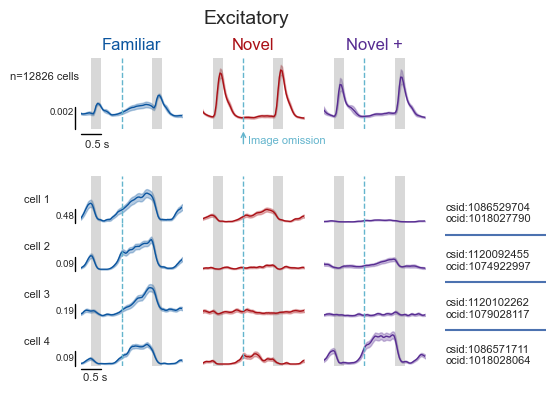

In [79]:
Exc_omission_cells = [ 1086529704, 1120092455, 1120102262, 1086571711,  1086514606, 
                      1086530117, 1120090879,  1086526518,]
event_type = 'omissions'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(omission_mdf, Exc_omission_cells[:4], cell_type, event_type=event_type, xlim_seconds=xlim_seconds,
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

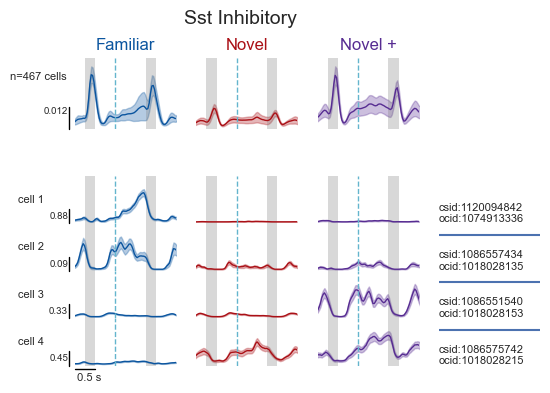

In [105]:
Sst_omission_cells = [1120094842,  1086557434, 1086551540, 1086575742, 1086569242, 
                     1086620900,  1086556653, 1086559850, 1086619649,]

event_type = 'omissions'

cell_type = 'Sst Inhibitory'
pse.plot_reliable_example_cells(omission_mdf, Sst_omission_cells[:4], cell_type, event_type=event_type, xlim_seconds=xlim_seconds,
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

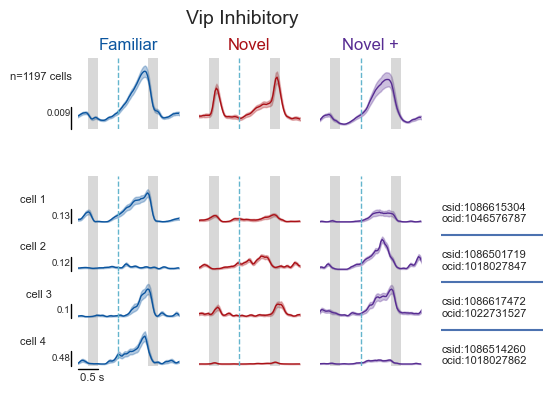

In [106]:
Vip_omission_cells = [1086615304, 1086501719, 1086617472, 1086514260, 1086616294, 1086514444, 
                      1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]

# Vip_omission_cells = [1086615304, 1086618157, 1086617472, 1086616294, 1086509523, 1086627590, 
#                       1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]

event_type = 'omissions'

cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(omission_mdf, Vip_omission_cells[:4], cell_type, event_type=event_type, xlim_seconds=xlim_seconds,
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from omission (s)'>, <Axes: >], dtype=object)

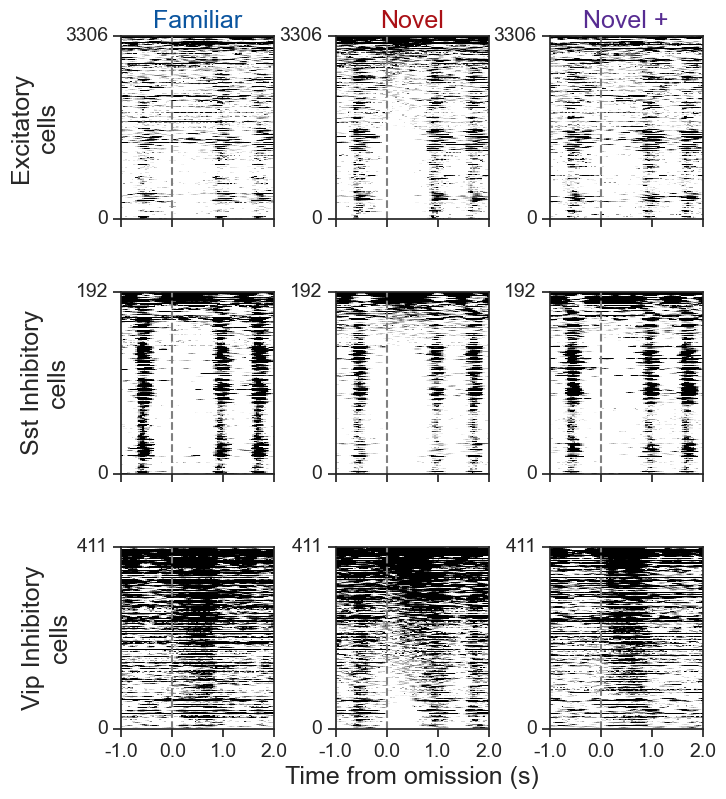

In [108]:
# Population averages for omissions - heatmaps
timestamps = omission_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

# Cell-matched omission heatmaps
matched_omissions = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(omission_mdf)

ppf.plot_response_heatmaps_for_conditions(
    matched_omissions, timestamps, data_type, 'omissions', row_condition, col_condition,
    cols_to_sort_by=None, suptitle='Matched cells - Omissions',
    xlabel='Time from omission (s)',
    microscope=None, xlim_seconds=[-1, 2], match_cells=True, cbar=False,
    save_dir=save_dir, folder=folder, suffix='_matched_omissions', ax=None)

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from image omission (s)'>, <Axes: >],
      dtype=object)

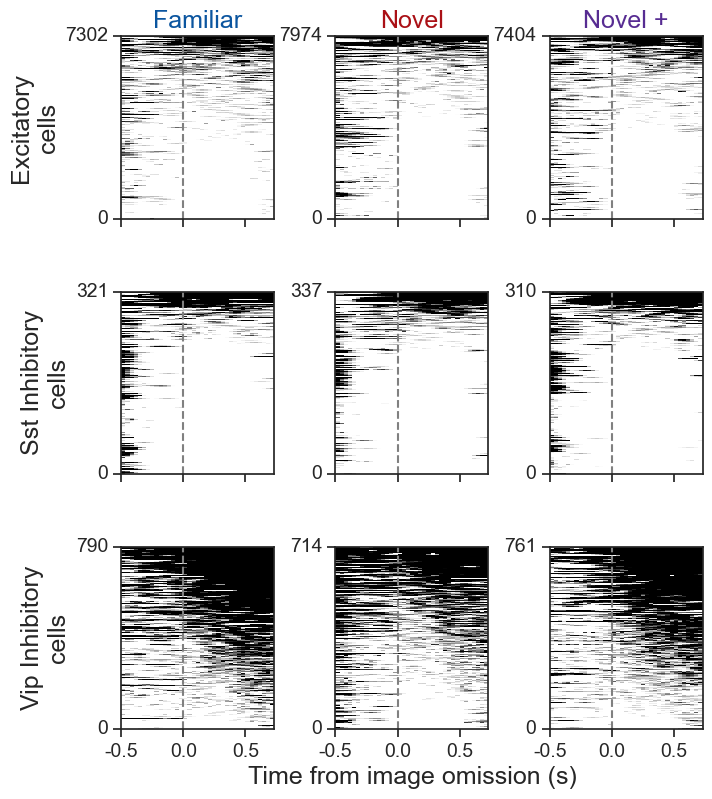

In [115]:
df = omission_mdf.copy()

xlim_seconds = [-0.5, 0.75]

event_type = 'all'

timestamps = df.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'
cols_to_sort_by = ['mean_response']

ppf.plot_response_heatmaps_for_conditions(df, timestamps, data_type, event_type, row_condition, col_condition, 
                                          cols_to_sort_by=cols_to_sort_by, suptitle='', xlabel='Time from image omission (s)',
                                          microscope=None, vmax=None, xlim_seconds=xlim_seconds, match_cells=False, cbar=False,
                                          save_dir=None, folder=folder, suffix='_heatmap_omissions', ax=None)

### Panel B: Population averages for image changes

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments


array([<Axes: title={'center': 'Familiar'}>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Calcium events'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time from image change (s)'>, <Axes: >],
      dtype=object)

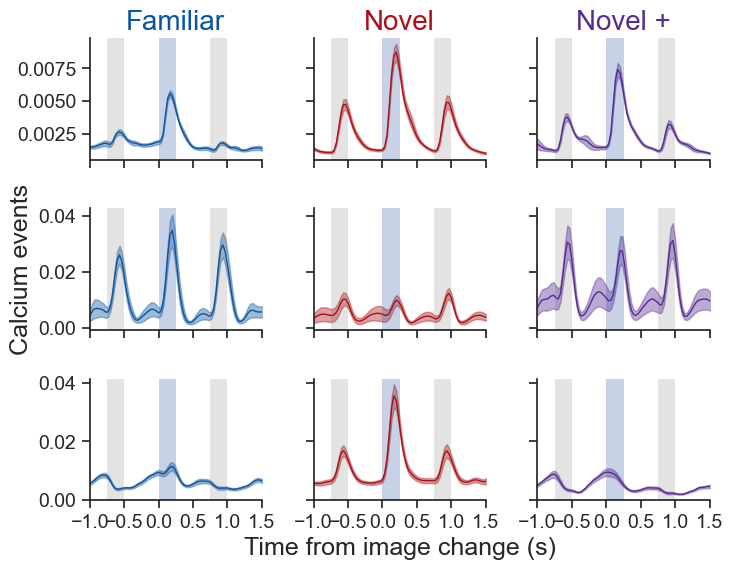

In [ ]:
df = change_mdf.copy()
xlim_seconds = [-1., 1.5]

ppf.plot_population_averages_for_cell_types_across_experience(
    df, xlim_seconds=xlim_seconds, xlabel='Time from image change (s)',
    ylabel='Calcium events', data_type=data_type, event_type='changes',
    interval_sec=1, save_dir=save_dir, folder='population_activity',
    suffix='_changes_stacked', ax=None)

### Panel F: Fraction of responsive cells

In [84]:
# folder = 'response_metrics'

# # Get single cell example for display
# cell_specimen_id = matched_cells[0]
# cell_metadata = matched_cells_table[matched_cells_table.cell_specimen_id == cell_specimen_id]

# # Plot matched ROI and trace for example cell
# ppf.plot_matched_roi_and_trace(cell_metadata.ophys_container_id.values[0], cell_specimen_id,
#                                limit_to_last_familiar_second_novel=True,
#                                use_events=True, filter_events=False, save_figure=False)

# # Plot matched ROI and traces example for cell with omissions
# ppf.plot_matched_roi_and_traces_example(cell_metadata, include_omissions=True,
#                                         use_events=True, filter_events=False, save_dir=save_dir,
#                                         folder='single_cell_examples')



In [ ]:
# Sort cells by response in a time window
xlim_seconds = [-1., 1.5]
timestamps = change_mdf.trace_timestamps.values[0]
# Build dff_traces DataFrame expected by sort function: indexed by cell_specimen_id with 'dff' column
# change_mdf has per-cell mean_trace values; we need one row per cell with the trace in a 'dff' column
dff_traces_for_sort = change_mdf.drop_duplicates(subset='cell_specimen_id').set_index('cell_specimen_id')[['mean_trace']].rename(columns={'mean_trace': 'dff'})
csids_sorted = ppf.sort_trace_csids_by_max_in_window(dff_traces_for_sort, timestamps, xlim_seconds)



401
Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1239: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1239: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1239: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


saving_stats


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Image change responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

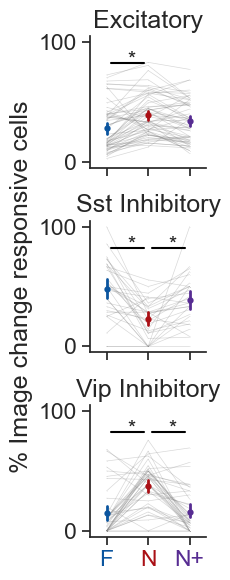

In [102]:
df = each_image_mdf[(each_image_mdf.is_change==True)& (each_image_mdf.pref_stim==True)]
print(len(df.ophys_experiment_id.unique()))

ppf.plot_percent_responsive_cells(df, responsiveness_threshold=0.2, ylim=(-5, 105), ylabel='% Image change responsive cells',
                                    save_dir=save_dir, folder =folder, suffix='_changes_pref_stim', horizontal=False, ax=None)


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  :param multi_session_df: dataframe of trial averaged responses for each cell for some set of conditions
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  :param multi_session_df: dataframe of trial averaged responses for each cell for some set of conditions
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  :param multi_session_df: datafram

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Fraction of image change responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

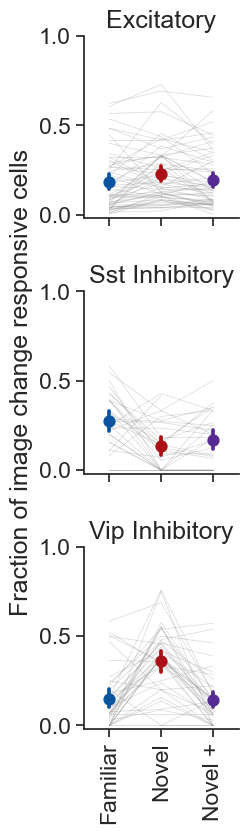

In [93]:

# Fraction of responsive cells for changes
ppf.plot_fraction_responsive_cells(
    change_mdf, responsiveness_threshold=0.1, ylim=(-0.02, 1),
    ylabel='Fraction of image change responsive cells',
    save_dir=save_dir, folder=folder, suffix='_changes_responsive',
    horizontal=False, ax=None)


Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1239: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1239: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1239: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


saving_stats


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Omission responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

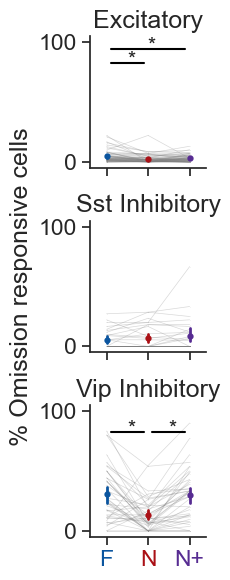

In [94]:
# Responsive cell fractions for omissions
ppf.plot_percent_responsive_cells(
    omission_mdf, responsiveness_threshold=0.1, ylim=(-5, 105),
    ylabel='% Omission responsive cells',
    save_dir=save_dir, folder=folder, suffix='_omissions_responsive',
    horizontal=False, ax=None)

### Mean response quantification

saving_stats


array([<Axes: title={'center': 'Excitatory\n(n = 12826 cells)'}>,
       <Axes: title={'center': 'Sst Inhibitory\n(n = 468 cells)'}, ylabel='Mean image change response'>,
       <Axes: title={'center': 'Vip Inhibitory\n(n = 1201 cells)'}>],
      dtype=object)

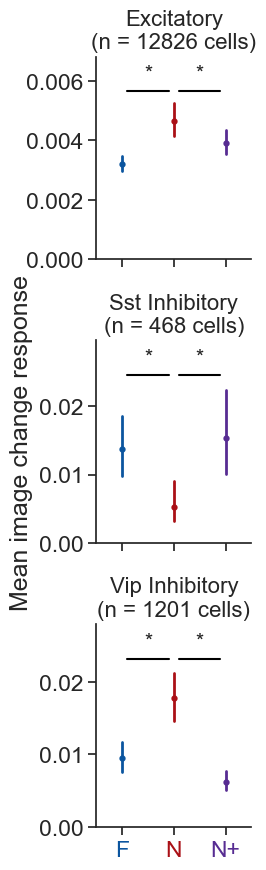

In [98]:
metric = 'mean_response_changes'
ylabel = 'Mean image change response'
event_type = 'changes'

ppf.plot_metric_distribution_by_experience(
    metrics_table, metric, plot_type='pointplot', horiz=False,
    suptitle='',
    add_zero_line=False, event_type=event_type, data_type=data_type,
    ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)

saving_stats


array([<Axes: title={'center': 'Excitatory\n(n = 12826 cells)'}>,
       <Axes: title={'center': 'Sst Inhibitory\n(n = 468 cells)'}, ylabel='Mean image omission response'>,
       <Axes: title={'center': 'Vip Inhibitory\n(n = 1201 cells)'}>],
      dtype=object)

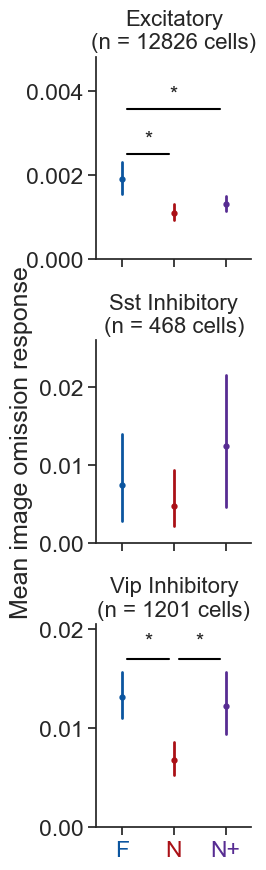

In [97]:
metric = 'mean_response_omissions'
ylabel = 'Mean image omission response'
event_type = 'omissions'

ppf.plot_metric_distribution_by_experience(
    metrics_table, metric, plot_type='pointplot', horiz=False,
    suptitle='',
    add_zero_line=False, event_type=event_type, data_type=data_type,
    ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)